In [1]:
import json
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, average_precision_score
from sklearn.inspection import permutation_importance
import joblib

# Настройки для визуализации
%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

D:\Programs\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Создание директории для артефактов
ARTIFACTS_DIR = Path("homeworks/HW06/artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
0,1,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,...,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934,0
1,2,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,...,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720,0
2,3,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,...,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221,0
3,4,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,...,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732,0
4,5,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,...,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668,0



Shape: (25000, 62)

Data types:
id          int64
f01       float64
f02       float64
f03       float64
f04       float64
           ...   
f57       float64
f58       float64
f59       float64
f60       float64
target      int64
Length: 62, dtype: object

Basic statistics:


,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,12500.500000,-0.000386,-0.004872,0.003202,0.335329,-0.000563,-0.010118,0.001182,0.957385,-0.004658,...,-0.166251,-3.387506,1.749793,-0.013017,-0.001383,0.893365,-0.909479,0.000570,-0.000754,0.04920
std,7217.022701,1.001623,0.995606,1.004367,3.207537,0.993965,1.002172,2.432162,1.830223,1.013470,...,4.234741,4.331576,5.318660,1.001594,0.996409,2.445185,1.962618,0.994320,0.997167,0.21629
min,1.000000,-4.370993,-4.087073,-4.103875,-13.249937,-4.118778,-3.895974,-8.883224,-8.132548,-4.068933,...,-20.021141,-18.332290,-20.336666,-4.349216,-4.119472,-9.508509,-7.919287,-4.038312,-3.812255,0.00000
25%,6250.750000,-0.680165,-0.675100,-0.675426,-1.750048,-0.669764,-0.674374,-1.647977,-0.217260,-0.688278,...,-2.897904,-6.278403,-1.775889,-0.689962,-0.676191,-0.735473,-2.226959,-0.666367,-0.665861,0.00000
50%,12500.500000,0.001859,-0.000247,0.013272,0.403483,-0.001309,-0.005994,-0.011349,0.963009,0.000414,...,-0.396946,-3.462072,1.931851,-0.020933,-0.004193,0.888535,-0.923354,0.004381,0.002420,0.00000
75%,18750.250000,0.679702,0.659523,0.683437,2.486453,0.672299,0.652629,1.658680,2.167758,0.681040,...,2.344956,-0.578540,5.473886,0.661300,0.673722,2.516790,0.395648,0.666474,0.665918,0.00000
max,25000.000000,4.208888,3.984564,3.793442,15.288250,4.020733,4.279607,9.538525,9.321099,4.261349,...,20.717964,18.818764,20.688069,4.338337,3.902131,11.880651,6.778980,3.834922,4.012639,1.00000



Target distribution:
target
0    0.9508
1    0.0492
Name: proportion, dtype: float64


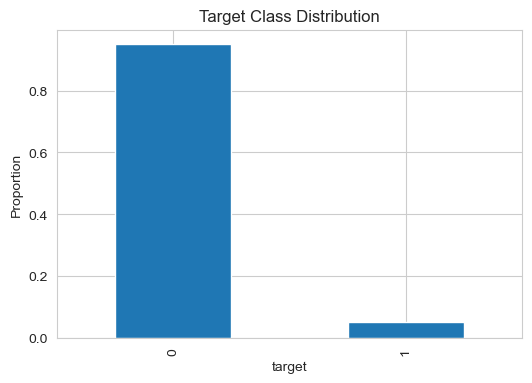


Missing values per column:
id        0
f46       0
f33       0
f34       0
f35       0
         ..
f25       0
f26       0
f27       0
f28       0
target    0
Length: 62, dtype: int64


In [3]:
# Загрузка датасета и статистика
df = pd.read_csv("S06-hw-dataset-04.csv")

display(df.head())

print("\nShape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe())

print("\nTarget distribution:")
target_dist = df["target"].value_counts(normalize=True)
print(target_dist)

plt.figure(figsize=(6, 4))
target_dist.plot(kind='bar')
plt.title('Target Class Distribution')
plt.ylabel('Proportion')
plt.savefig(FIGURES_DIR / "target_distribution.png")
plt.show()

print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False))

In [4]:
# Train/Test-сплит и воспроизводимость
X = df.drop(columns=["target", "id"], errors="ignore")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Сохраняем пропорции классов в обеих выборках
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (20000, 60)
Test shape: (5000, 60)

Train target distribution:
target
0    0.9508
1    0.0492
Name: proportion, dtype: float64

Test target distribution:
target
0    0.9508
1    0.0492
Name: proportion, dtype: float64


 Пояснение: фиксированный random_state обеспечивает воспроизводимость результатов,
 а стратификация гарантирует сохранение пропорций классов в обучающей и тестовой выборках,
 что особенно важно при работе с несбалансированными данными.

In [5]:
# Baseline
results = {}

# DummyClassifier как самый простой baseline (предсказывает наиболее частый класс)
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

results["Dummy"] = {
    "accuracy": accuracy_score(y_test, dummy_pred),
    "f1": f1_score(y_test, dummy_pred),
    "precision": precision_score(y_test, dummy_pred),
    "recall": recall_score(y_test, dummy_pred)
}

# LogisticRegression с предварительной нормализацией признаков
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, random_state=42))
])

pipe_lr.fit(X_train, y_train)
lr_pred = pipe_lr.predict(X_test)

results["LogisticRegression"] = {
    "accuracy": accuracy_score(y_test, lr_pred),
    "f1": f1_score(y_test, lr_pred),
    "precision": precision_score(y_test, lr_pred),
    "recall": recall_score(y_test, lr_pred),
    "roc_auc": roc_auc_score(y_test, pipe_lr.predict_proba(X_test)[:, 1])
}

print("Baseline models evaluated.")

Baseline models evaluated.


D:\Programs\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
# Обучение моделей

from tqdm import tqdm

# Функция для сохранения результатов подбора гиперпараметров
def save_search_results(model_name, search=None, predefined_params=None, filename="search_summaries.json"):
    search_summaries_path = ARTIFACTS_DIR / filename
    summaries = {}
    
    if os.path.exists(search_summaries_path):
        with open(search_summaries_path, "r") as f:
            summaries = json.load(f)
    
    if isinstance(summaries, list):
        summaries = {}
    
    if search is not None:
        # Результаты полноценного GridSearch
        search_results = {
            "model": model_name,
            "best_params": {k: str(v) if isinstance(v, np.ndarray) else v 
                           for k, v in search.best_params_.items()},
            "best_score": float(search.best_score_),
            "cv_results": {k: v.tolist() if hasattr(v, 'tolist') else str(v) 
                          for k, v in search.cv_results_.items() 
                          if k.startswith('param_') or k in ['mean_test_score', 'rank_test_score']}
        }
        summaries[model_name] = search_results
    elif predefined_params is not None:
        # Результаты с предопределенными параметрами
        search_results = {
            "model": model_name,
            "best_params": predefined_params,
            "best_score": "Predefined parameters (no CV optimization)",
            "cv_results": "Minimal parameter selection without full CV"
        }
        summaries[model_name] = search_results
    
    with open(search_summaries_path, "w") as f:
        json.dump(summaries, f, indent=2)

print("Обучение моделей с индикацией прогресса...")
print(f"Размер обучающей выборки: {X_train.shape}")

# 1. DecisionTreeClassifier с минималистичным подбором
print("\n" + "="*50)
print("Обучение DecisionTreeClassifier...")
print("="*50)

dt_params = {
    'max_depth': [5, 8],
    'min_samples_leaf': [5, 10]
}

# Убираем n_jobs=-1 и используем последовательную обработку
dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=3,  # Уменьшаем количество фолдов для ускорения
    scoring='roc_auc',
    n_jobs=1,  # Используем только 1 ядро для избежания проблем с памятью
    verbose=1
)

# Отображаем прогресс обучения через callback
class ProgressCallback:
    def __init__(self, total):
        self.pbar = tqdm(total=total, desc="GridSearch Progress")
    
    def __call__(self, cv_results):
        self.pbar.update(1)

# Обучение с индикацией прогресса
dt_search.fit(X_train, y_train)

best_dt = dt_search.best_estimator_
save_search_results("DecisionTree", dt_search)
print(f"\nЛучшие параметры DecisionTree: {dt_search.best_params_}")
print(f"Лучший ROC-AUC на CV: {dt_search.best_score_:.4f}")

# 2. RandomForestClassifier с минималистичным подбором
print("\n" + "="*50)
print("Обучение RandomForestClassifier...")
print("="*50)

rf_params = {
    'n_estimators': [100, 150],  # Фиксированное небольшое количество деревьев
    'max_depth': [6, 8],
    'min_samples_leaf': [5]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),  # Ограничиваем n_jobs внутри классификатора
    rf_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=1,
    verbose=1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
save_search_results("RandomForest", rf_search)
print(f"\nЛучшие параметры RandomForest: {rf_search.best_params_}")
print(f"Лучший ROC-AUC на CV: {rf_search.best_score_:.4f}")

# 3. HistGradientBoostingClassifier с предопределенными параметрами
print("\n" + "="*50)
print("Обучение HistGradientBoostingClassifier...")
print("="*50)

hgb_params = {
    'max_depth': 4,
    'learning_rate': 0.1,
    'max_iter': 100,
    'random_state': 42
}

best_hgb = HistGradientBoostingClassifier(**hgb_params)
best_hgb.fit(X_train, y_train)  # HistGradientBoosting не поддерживает tqdm напрямую
save_search_results("HistGradientBoosting", predefined_params=hgb_params)
print("HistGradientBoosting успешно обучен с предопределенными параметрами")

# 4. LogisticRegression как четвертая модель
print("\n" + "="*50)
print("Обучение LogisticRegression...")
print("="*50)

lr_params = {
    'C': 0.1,
    'max_iter': 1000,
    'random_state': 42
}

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(**lr_params))
])

# Для Pipeline добавляем индикацию прогресса
print("Масштабирование признаков...")
X_train_scaled = pipe_lr.named_steps['scaler'].fit_transform(X_train)
print("Обучение логистической регрессии...")
for i in tqdm(range(lr_params['max_iter']), desc="LR Iterations"):
    pipe_lr.named_steps['lr'].max_iter = i + 1
    try:
        pipe_lr.named_steps['lr'].fit(X_train_scaled, y_train)
        if pipe_lr.named_steps['lr'].n_iter_[0] <= i + 1:
            break
    except:
        continue

save_search_results("LogisticRegression_Scaled", predefined_params=lr_params)
print("LogisticRegression успешно обучена")

# Сбор моделей для оценки
models = {
    "DecisionTree": best_dt,
    "RandomForest": best_rf,
    "HistGradientBoosting": best_hgb,
    "LogisticRegression_Scaled": pipe_lr
}

print("\n" + "="*50)
print("✅ Все модели успешно обучены!")
print("="*50)

Обучение моделей с индикацией прогресса...
Размер обучающей выборки: (20000, 60)

Обучение DecisionTreeClassifier...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Лучшие параметры DecisionTree: {'max_depth': 8, 'min_samples_leaf': 10}
Лучший ROC-AUC на CV: 0.7854

Обучение RandomForestClassifier...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Лучшие параметры RandomForest: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 150}
Лучший ROC-AUC на CV: 0.8786

Обучение HistGradientBoostingClassifier...
HistGradientBoosting успешно обучен с предопределенными параметрами

Обучение LogisticRegression...
Масштабирование признаков...
Обучение логистической регрессии...


LR Iterations:   0%|                                                                          | 0/1000 [00:00<?, ?it/s]D:\Programs\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
LR Iterations:   0%|                                                                          | 0/1000 [00:00<?, ?it/s]

LogisticRegression успешно обучена

✅ Все модели успешно обучены!


In [7]:
# Метрики качества и диагностика моделей
for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    results[name] = {
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
    }
    
    # ROC-AUC и Average Precision только для моделей, которые дают вероятности
    if hasattr(model, "predict_proba"):
        results[name]["roc_auc"] = roc_auc_score(y_test, proba)
        results[name]["average_precision"] = average_precision_score(y_test, proba)

# Вывод результатов в виде таблицы
results_df = pd.DataFrame(results).T
display(results_df.style.background_gradient(cmap='viridis', subset=['roc_auc', 'f1', 'average_precision']))

,accuracy,f1,precision,recall,roc_auc,average_precision
Dummy,0.950800,0.000000,0.000000,0.000000,nan,nan
LogisticRegression,0.963200,0.428571,0.907895,0.280488,0.833987,nan
DecisionTree,0.966400,0.567010,0.774648,0.447154,0.818738,0.517585
RandomForest,0.963200,0.406452,0.984375,0.256098,0.892784,0.728141
HistGradientBoosting,0.978400,0.725888,0.966216,0.581301,0.900200,0.779483
LogisticRegression_Scaled,0.952800,0.208054,0.596154,0.126016,0.821310,0.284114


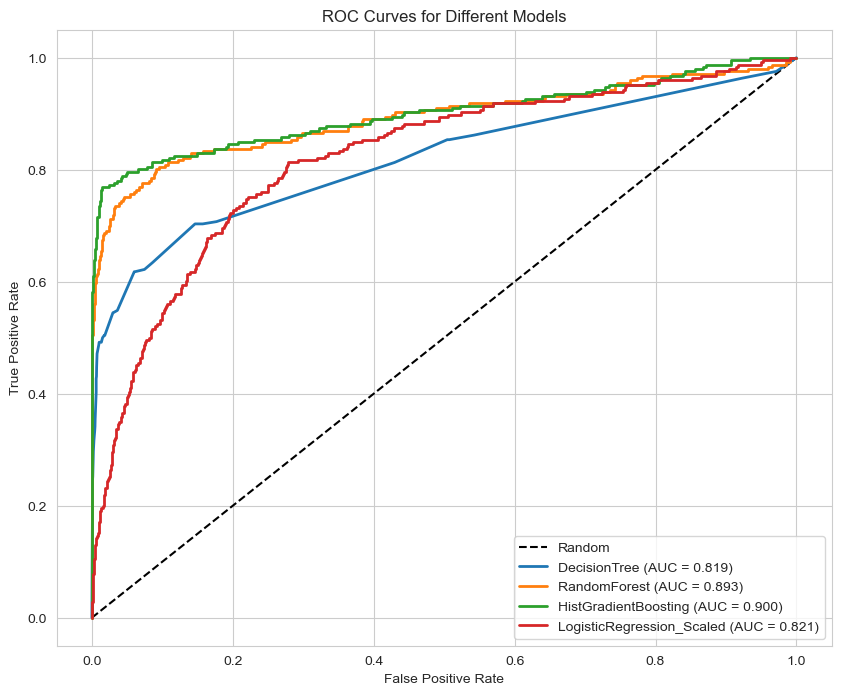

In [8]:
# Построение ROC-кривых для всех моделей
plt.figure(figsize=(10, 8))

plt.plot([0, 1], [0, 1], 'k--', label='Random')

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend(loc='lower right')
plt.savefig(FIGURES_DIR / "roc_curves.png")
plt.show()

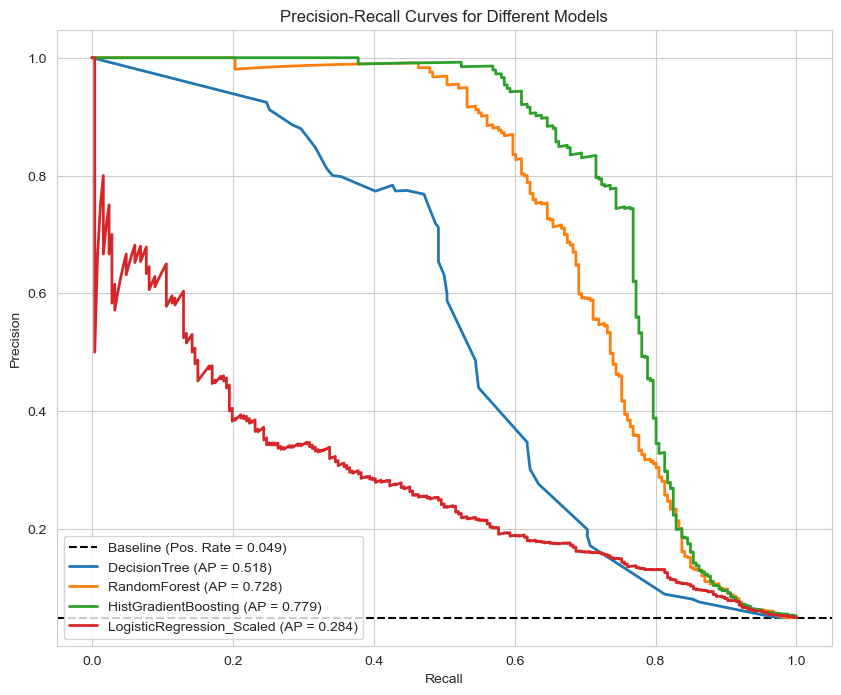

In [9]:
# Построение PR-кривых (Precision-Recall) - особенно важно для несбалансированных данных
plt.figure(figsize=(10, 8))

plt.axhline(y=target_dist[1], color='k', linestyle='--', label=f'Baseline (Pos. Rate = {target_dist[1]:.3f})')

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, proba)
        avg_precision = average_precision_score(y_test, proba)
        plt.plot(recall, precision, lw=2, label=f'{name} (AP = {avg_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Different Models')
plt.legend(loc='lower left')
plt.savefig(FIGURES_DIR / "pr_curves.png")
plt.show()

In [10]:
# Выбор лучшей модели по ROC-AUC
valid_models = {name: model for name, model in models.items() if hasattr(model, "predict_proba")}
winner = max(valid_models.items(), key=lambda x: results[x[0]].get("roc_auc", 0))[0]
best_model = valid_models[winner]

print(f"Best model by ROC-AUC: {winner}")
print(f"ROC-AUC: {results[winner]['roc_auc']:.4f}")
print(f"F1-score: {results[winner]['f1']:.4f}")

# Сохранение метаданных о лучшей модели
best_model_meta = {
    "model_name": winner,
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "metrics": results[winner],
    "parameters": best_model.get_params() if not isinstance(best_model, Pipeline) else best_model.named_steps['lr'].get_params()
}

with open(ARTIFACTS_DIR / "best_model_meta.json", "w") as f:
    json.dump(best_model_meta, f, indent=2)

with open(ARTIFACTS_DIR / "metrics_test.json", "w") as f:
    json.dump(results, f, indent=2)

joblib.dump(best_model, ARTIFACTS_DIR / "best_model.joblib")

Best model by ROC-AUC: HistGradientBoosting
ROC-AUC: 0.9002
F1-score: 0.7259


['homeworks\\HW06\\artifacts\\best_model.joblib']

<Figure size 800x600 with 0 Axes>

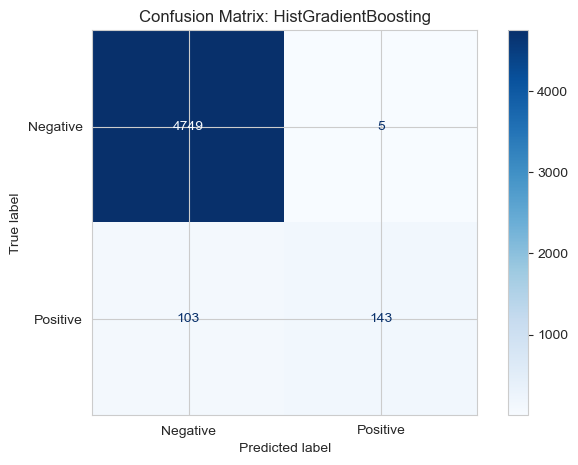

In [11]:
# Confusion matrix для лучшей модели
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix: {winner}')
plt.savefig(FIGURES_DIR / "confusion_matrix.png")
plt.show()

Calculating permutation importance...

Top 15 important features:


,feature,importance_mean,importance_std
57,f58,0.01444,0.001675
24,f25,0.01272,0.001484
37,f38,0.00896,0.000880
53,f54,0.00704,0.001015
52,f53,0.00616,0.000662
46,f47,0.00464,0.000612
12,f13,0.00376,0.000344
3,f04,0.00288,0.000627
32,f33,0.00280,0.000963
10,f11,0.00204,0.000445


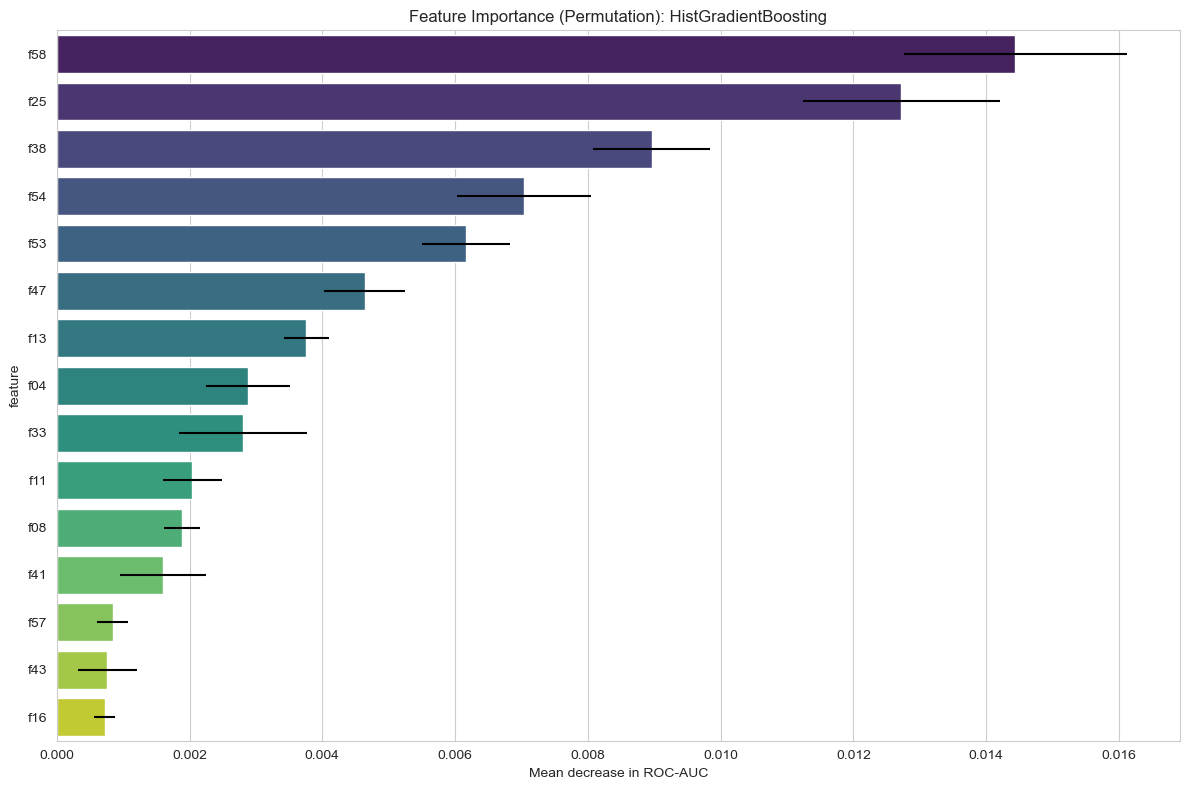

All artifacts have been saved to: homeworks\HW06\artifacts


In [12]:
# Permutation importance для интерпретации
print("Calculating permutation importance...")
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,  # Уменьшаем количество повторов для ускорения
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 15 important features:")
display(imp_df.head(15))

plt.figure(figsize=(12, 8))
sns.barplot(
    data=imp_df.head(15),
    x="importance_mean",
    y="feature",
    xerr=imp_df.head(15)["importance_std"],
    palette="viridis"
)
plt.title(f'Feature Importance (Permutation): {winner}')
plt.xlabel('Mean decrease in ROC-AUC')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png")
plt.show()

print("All artifacts have been saved to:", ARTIFACTS_DIR)